In [9]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as kh
import os
import keras

from sklearn.preprocessing import MinMaxScaler
from helper import *
from keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input, BatchNormalization

In [ ]:
training = False
plt.rcParams.update({'text.usetex': False})

In [11]:
tf.random.set_seed(42)

In [12]:
path = kh.dataset_download("palbha/cmapss-jet-engine-simulated-data")

In [13]:
col_names = ['Unit', 'Cycle Time'] + [f'Sensor {_+1}' for _ in range(26)]
df = pd.read_csv(os.path.join(path, 'train_FD001.txt'), sep=' ', header=None, names=col_names)
df_test = pd.read_csv(os.path.join(path, 'test_FD001.txt'), sep=' ', header=None, names=col_names)

In [14]:
df.head()

,Unit,Cycle Time,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,...,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23,Sensor 24,Sensor 25,Sensor 26
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [15]:
# Using to_string with specific formatting
with open('data_summary_FD001.txt', 'w') as f:
    f.write("CMAPSS Dataset Summary Statistics\n")
    f.write("="*30 + "\n")
    f.write(df.describe().transpose().to_string()) # Transpose makes it easier to read if you have many sensors

In [16]:
cols_to_drop = ['Sensor 3', 'Sensor 21', 'Sensor 22', 'Sensor 25', 'Sensor 26']
relevant_sensors = [f'Sensor {_+1}' for _ in range(26) if _ not in (2, 20, 21, 24, 25)]
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
df.head()

,Unit,Cycle Time,Sensor 1,Sensor 2,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 23,Sensor 24
0,1,1,-0.0007,-0.0004,518.67,641.82,1589.70,1400.60,14.62,21.61,...,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,39.06,23.4190
1,1,2,0.0019,-0.0003,518.67,642.15,1591.82,1403.14,14.62,21.61,...,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,39.00,23.4236
2,1,3,-0.0043,0.0003,518.67,642.35,1587.99,1404.20,14.62,21.61,...,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,38.95,23.3442
3,1,4,0.0007,0.0000,518.67,642.35,1582.79,1401.87,14.62,21.61,...,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,518.67,642.37,1582.85,1406.22,14.62,21.61,...,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,38.90,23.4044


In [17]:
# Initialize Scaler
scaler = MinMaxScaler()

# Fit only on what we consider "healthy" data (e.g., first 30 cycles of each unit)
healthy_data = df.groupby('Unit').head(30)
scaler.fit(healthy_data[relevant_sensors])

# Transform both datasets
df[relevant_sensors] = scaler.transform(df[relevant_sensors])
df_test[relevant_sensors] = scaler.transform(df_test[relevant_sensors])

# Helper function to create overlapping windows/sequences
def create_sequences(values, time_steps=10):
    output = []
    for i in range(len(values) - time_steps + 1):
        output.append(values[i : (i + time_steps)])
    return np.stack(output)

# Create sequences for a specific unit (to keep sequences within engine boundaries)
def get_unit_sequences(data, unit_id, time_steps=10):
    unit_data = data[data['Unit'] == unit_id][relevant_sensors].values
    if len(unit_data) < time_steps:
        return None
    return create_sequences(unit_data, time_steps)

# Generate training sequences from the healthy portions of all engines
X_train = np.concatenate([get_unit_sequences(df, u) for u in df['Unit'].unique() if get_unit_sequences(df, u) is not None])

In [18]:
TIME_STEPS = X_train.shape[1]
N_FEATURES = X_train.shape[2]

model = keras.Sequential([
    # Encoder
    Input(shape=(TIME_STEPS, N_FEATURES)),
    LSTM(64, activation='relu', return_sequences=False),
    RepeatVector(TIME_STEPS),
    
    # Decoder
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(N_FEATURES))
])

model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                22016     
                                                                 
 repeat_vector (RepeatVector  (None, 10, 64)           0         
 )                                                               
                                                                 
 lstm_1 (LSTM)               (None, 10, 64)            33024     
                                                                 
 time_distributed (TimeDistr  (None, 10, 21)           1365      
 ibuted)                                                         
                                                                 
Total params: 56,405
Trainable params: 56,405
Non-trainable params: 0
_________________________________________________________________


In [19]:
if training:
    history = model.fit(
        X_train, X_train,
        epochs=30,
        batch_size=32,
        validation_split=0.1,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)]
    ).history

# Calculate the Reconstruction Error (MAE)
X_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=(1, 2))

# Set threshold at the 99th percentile of training error
threshold = np.percentile(train_mae_loss, 99)
print(f"Reconstruction error threshold: {threshold}")

617/617 [==============================] - 3s 4ms/step
Reconstruction error threshold: 0.7070694822213875


1/1 [==============================] - 0s 15ms/step


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

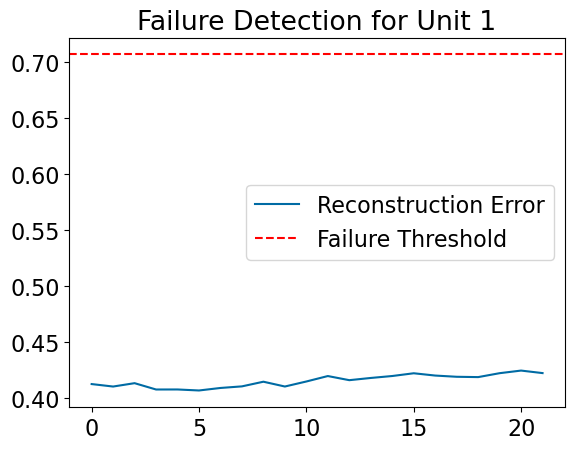

In [ ]:
# Pick one engine from test set to visualize
test_unit_1 = get_unit_sequences(df_test, 1)
test_unit_1_pred = model.predict(test_unit_1)
test_unit_1_loss = np.mean(np.abs(test_unit_1_pred - test_unit_1), axis=(1, 2))

plt.plot(test_unit_1_loss, label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Failure Threshold')
plt.title("Failure Detection for Unit 1")
plt.legend()
plt.show()